In [79]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [80]:
internal_data_analysis_dir = os.path.dirname(os.path.abspath('Data_visualization.ipynb'))
root_dir = os.path.abspath(os.path.join(internal_data_analysis_dir, '..'))
internal_data_collection_dir = os.path.abspath(os.path.join(internal_data_analysis_dir, 'May_07'))
print(f'The directory of data analysis : {internal_data_analysis_dir}')
print(f'The root directory of this project : {root_dir}')
print(f'The directory of collected data : {internal_data_collection_dir}')

The directory of data analysis : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results
The root directory of this project : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control
The directory of collected data : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_07


In [81]:
#MPC_Data_dir = os.path.abspath(os.path.join(internal_data_collection_dir, 'MPC_controller_data'))
PD_data_dir = os.path.abspath(os.path.join(internal_data_collection_dir, 'PD_controller_data'))
#step_data_file_dir = os.path.abspath(os.path.join(internal_data_collection_dir, 'New_New_New_Data_CSV'))

In [82]:
# for file in os.listdir(MPC_Data_dir):
#     print(os.path.join(MPC_Data_dir, file))  

In [83]:
for file in os.listdir(PD_data_dir):
    print(os.path.join(PD_data_dir, file)) 

c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_07\PD_controller_data\data_may_7_pdc_1_S1.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_07\PD_controller_data\data_may_7_pdc_1_S3.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_07\PD_controller_data\data_may_7_pdc_2_S1.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_07\PD_controller_data\data_may_7_pdc_2_S3.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_07\PD_controller_data\data_may_7_pdc_3_S3.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_07\PD_controller_data\Logged_Pd_CS_1
c:\Users\home\Desktop\ACC\Auto-Cruise

In [84]:
# Load data from the CSV files in the specified directories
# mpc_data_files = [os.path.join(MPC_Data_dir, file) for file in os.listdir(MPC_Data_dir) if file.endswith('.csv')]
pd_data_files = [os.path.join(PD_data_dir, file) for file in os.listdir(PD_data_dir) if file.endswith('.csv')]

# Load the data into dataframes
# mpc_dataframes = [pd.read_csv(file) for file in mpc_data_files]
pd_dataframes = [pd.read_csv(file) for file in pd_data_files]

# Print the number of files loaded
# print(f"Loaded {len(mpc_dataframes)} MPC data files.")
print(f"Loaded {len(pd_dataframes)} PD data files.")

Loaded 5 PD data files.


In [85]:
# Display the first few rows of each MPC dataframe
# print("MPC Dataframes:")
# for i, df in enumerate(mpc_dataframes):
#     print(f"\nMPC Dataframe {i+1}:")
#     print(df.head())



In [86]:
# Display the first few rows of each PD dataframe
print("\nPD Dataframes:")
for i, df in enumerate(pd_dataframes):
    print(f"\nPD Dataframe {i+1}:")
    print(df.head())


PD Dataframes:

PD Dataframe 1:
   Ego_Position(m)  Ego_Velocity(m/s)   Time(s)
0              0.0                0.0  0.000019
1              0.0                0.0  0.051444
2              0.0                0.0  0.160856
3              0.0                0.0  0.271341
4              0.0                0.0  0.380744

PD Dataframe 2:
   Ego_Position(m)  Ego_Velocity(m/s)   Time(s)
0              0.0                0.0  0.000015
1              0.0                0.0  0.079162
2              0.0                0.0  0.188159
3              0.0                0.0  0.298738
4              0.0                0.0  0.409692

PD Dataframe 3:
   Ego_Position(m)  Ego_Velocity(m/s)   Time(s)
0              0.0                0.0  0.000018
1              0.0                0.0  0.043239
2              0.0                0.0  0.152975
3              0.0                0.0  0.262414
4              0.0                0.0  0.371818

PD Dataframe 4:
   Ego_Position(m)  Ego_Velocity(m/s)   Time(s)
0   

In [87]:
# Function to clean data by removing rows with invalid Remaining Distance or Ego Position values
def cleaning_data(df):
    # Check if the required columns exist and filter rows
    if "Remaining Distance (m)" in df.columns:
        df = df[(df["Remaining Distance (m)"] >= 0) & (df["Remaining Distance (m)"] <= 110)]
    if "Ego_Position(m)" in df.columns:
        df = df[(df["Ego_Position(m)"] >= 0) & (df["Ego_Position(m)"] <= 110)]
    return df

# Apply the cleaning function to all MPC and PD dataframes
# mpc_dataframes = [cleaning_data(df) for df in mpc_dataframes]
pd_dataframes = [cleaning_data(df) for df in pd_dataframes]

print("Data cleaned. Rows with Remaining Distance (m) or Ego_Position(m) > 110 or < 0 have been removed.")

Data cleaned. Rows with Remaining Distance (m) or Ego_Position(m) > 110 or < 0 have been removed.


In [88]:

# Plot Distance vs Time and Velocity vs Time for each dataframe
# for i, df in enumerate(mpc_dataframes):
#     print(f"\nMPC Dataframe {i+1} - Plotting Distance and Velocity:")
    
#     # Check if the required columns exist
#     if "Time (s)" in df.columns and "Remaining Distance (m)" in df.columns and "Velocity (m/s)" in df.columns:
#         plt.figure(figsize=(15, 8))

#         # Distance vs Time
#         plt.subplot(2, 2, 1)
#         plt.plot(df["Time (s)"], df["Remaining Distance (m)"], label="Distance", color="blue")
#         plt.ylabel("Distance (m)")
#         plt.title(f"MPC Dataframe {i+1} - Distance vs Time")
#         plt.grid(True)
#         plt.legend()

#         # Velocity vs Time
#         plt.subplot(2, 2, 2)
#         plt.plot(df["Time (s)"], df["Velocity (m/s)"], label="Velocity", color="green")
#         plt.xlabel("Time (s)")
#         plt.ylabel("Velocity (m/s)")
#         plt.title(f"MPC Dataframe {i+1} - Velocity vs Time")
#         plt.grid(True)
#         plt.legend()

#         plt.tight_layout()
#         plt.show()
#     elif "Time(s)" in df.columns and "Ego_Position(m)" in df.columns and "Ego_Velocity(m/s)" in df.columns:
#         plt.figure(figsize=(15, 8))
#         print(f"These dataframes are autologged during testing {i+1}")
#         # Distance vs Time
#         plt.subplot(2, 2, 1)
#         plt.plot(df["Time(s)"], df["Ego_Position(m)"], label="Distance", color="blue")
#         plt.ylabel("Distance (m)")
#         plt.title(f"MPC Dataframe {i+1} - Distance vs Time")
#         plt.grid(True)
#         plt.legend()

#         # Velocity vs Time
#         plt.subplot(2, 2, 2)
#         plt.plot(df["Time(s)"], df["Ego_Velocity(m/s)"], label="Velocity", color="green")
#         plt.xlabel("Time (s)")
#         plt.ylabel("Velocity (m/s)")
#         plt.title(f"MPC Dataframe {i+1} - Velocity vs Time")
#         plt.grid(True)
#         plt.legend()

#         plt.tight_layout()
#         plt.show()
#     else:
#         print(f"Dataframe {i+1} does not contain the required columns for plotting.")




PD Dataframe 1 - Plotting Distance and Velocity:
These dataframes are autologged during testing 1


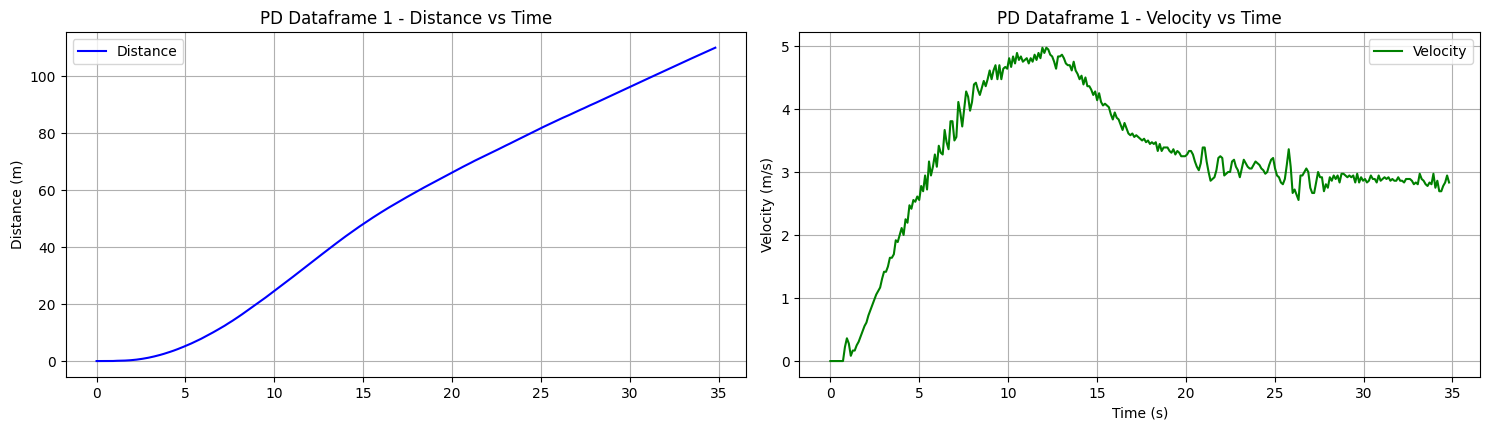


PD Dataframe 2 - Plotting Distance and Velocity:
These dataframes are autologged during testing 2


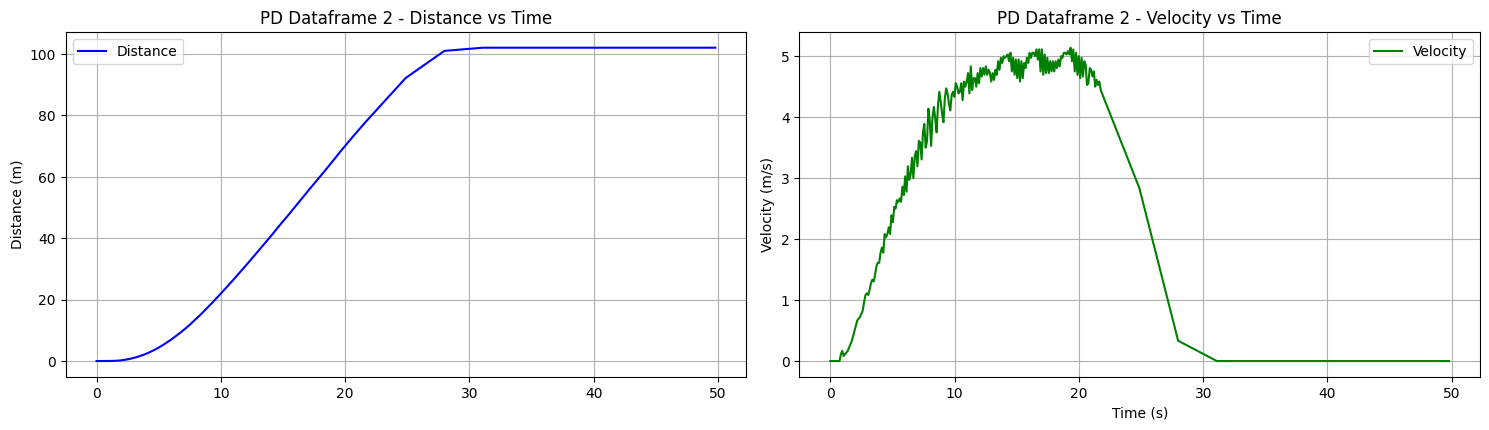


PD Dataframe 3 - Plotting Distance and Velocity:
These dataframes are autologged during testing 3


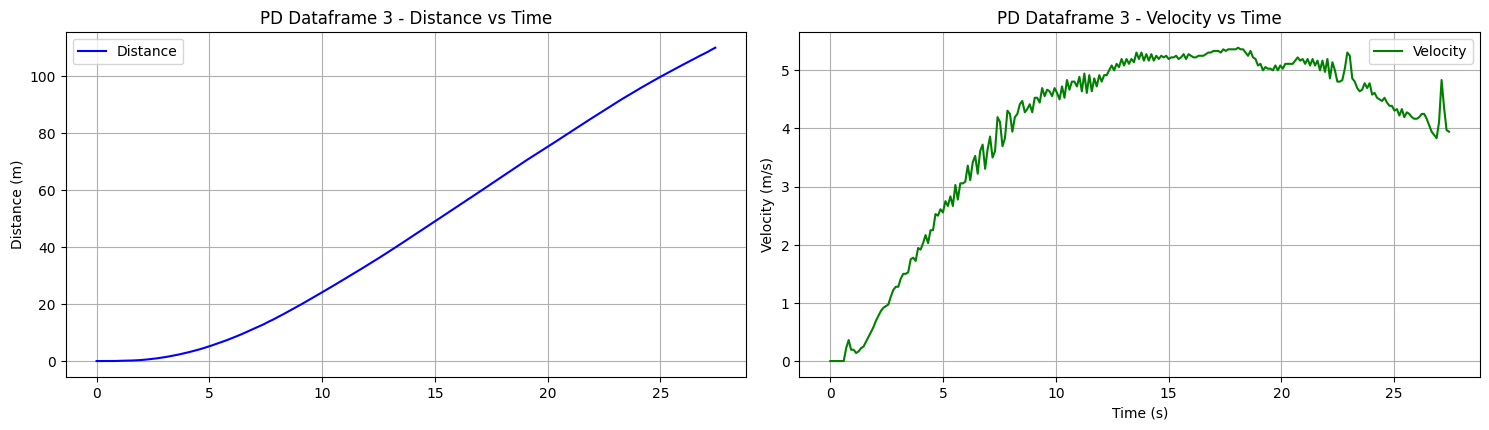


PD Dataframe 4 - Plotting Distance and Velocity:
These dataframes are autologged during testing 4


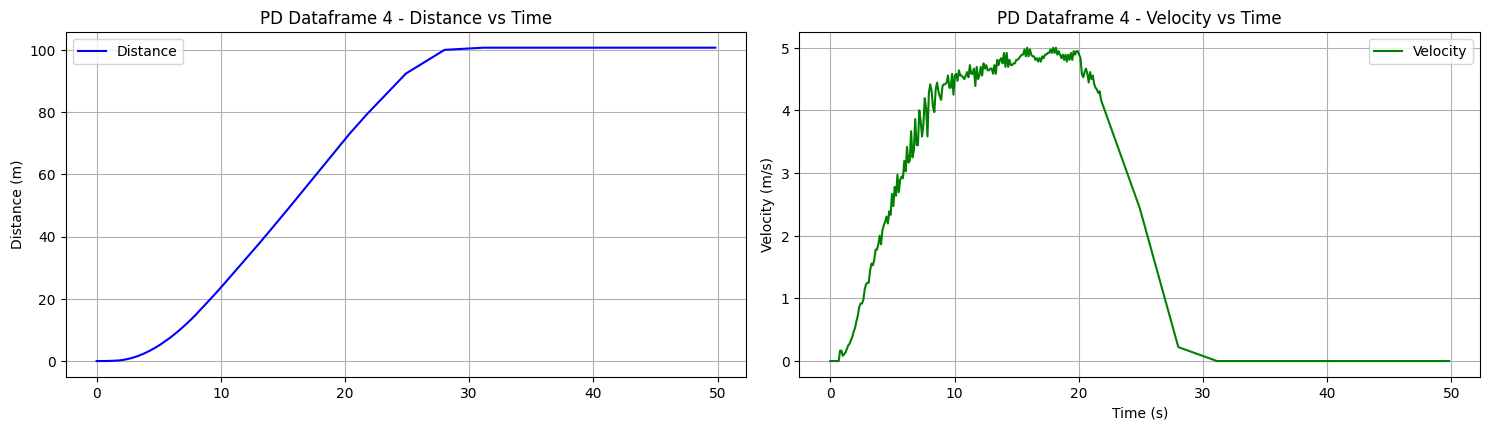


PD Dataframe 5 - Plotting Distance and Velocity:
These dataframes are autologged during testing 5


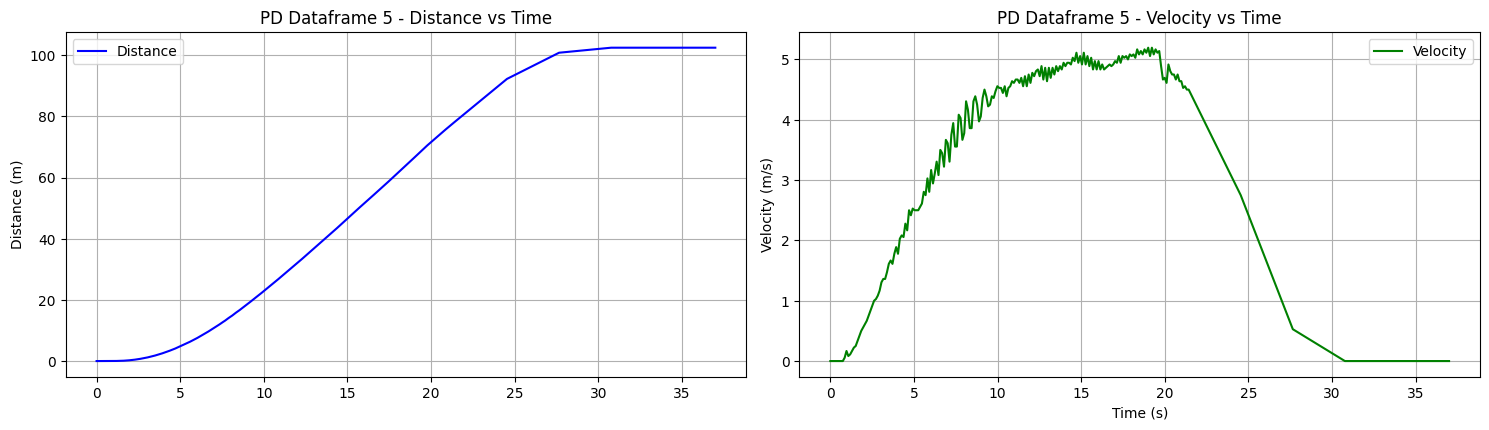

In [89]:

# Plot Distance vs Time and Velocity vs Time for each dataframe
for i, df in enumerate(pd_dataframes):
    print(f"\nPD Dataframe {i+1} - Plotting Distance and Velocity:")
    
    # Check if the required columns exist
    if "Time (s)" in df.columns and "Remaining Distance (m)" in df.columns and "Velocity (m/s)" in df.columns:
        plt.figure(figsize=(15, 8))

        # Distance vs Time
        plt.subplot(2, 2, 1)
        plt.plot(df["Time (s)"], df["Remaining Distance (m)"], label="Distance", color="blue")
        plt.ylabel("Distance (m)")
        plt.title(f"PD Dataframe {i+1} - Distance vs Time")
        plt.grid(True)
        plt.legend()

        # Velocity vs Time
        plt.subplot(2, 2, 2)
        plt.plot(df["Time (s)"], df["Velocity (m/s)"], label="Velocity", color="green")
        plt.xlabel("Time (s)")
        plt.ylabel("Velocity (m/s)")
        plt.title(f"PD Dataframe {i+1} - Velocity vs Time")
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()
    elif "Time(s)" in df.columns and "Ego_Position(m)" in df.columns and "Ego_Velocity(m/s)" in df.columns:
        plt.figure(figsize=(15, 8))
        print(f"These dataframes are autologged during testing {i+1}")
        # Distance vs Time
        plt.subplot(2, 2, 1)
        plt.plot(df["Time(s)"], df["Ego_Position(m)"], label="Distance", color="blue")
        plt.ylabel("Distance (m)")
        plt.title(f"PD Dataframe {i+1} - Distance vs Time")
        plt.grid(True)
        plt.legend()

        # Velocity vs Time
        plt.subplot(2, 2, 2)
        plt.plot(df["Time(s)"], df["Ego_Velocity(m/s)"], label="Velocity", color="green")
        plt.xlabel("Time (s)")
        plt.ylabel("Velocity (m/s)")
        plt.title(f"PD Dataframe {i+1} - Velocity vs Time")
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()
    else:
        print(f"Dataframe {i+1} does not contain the required columns for plotting.")






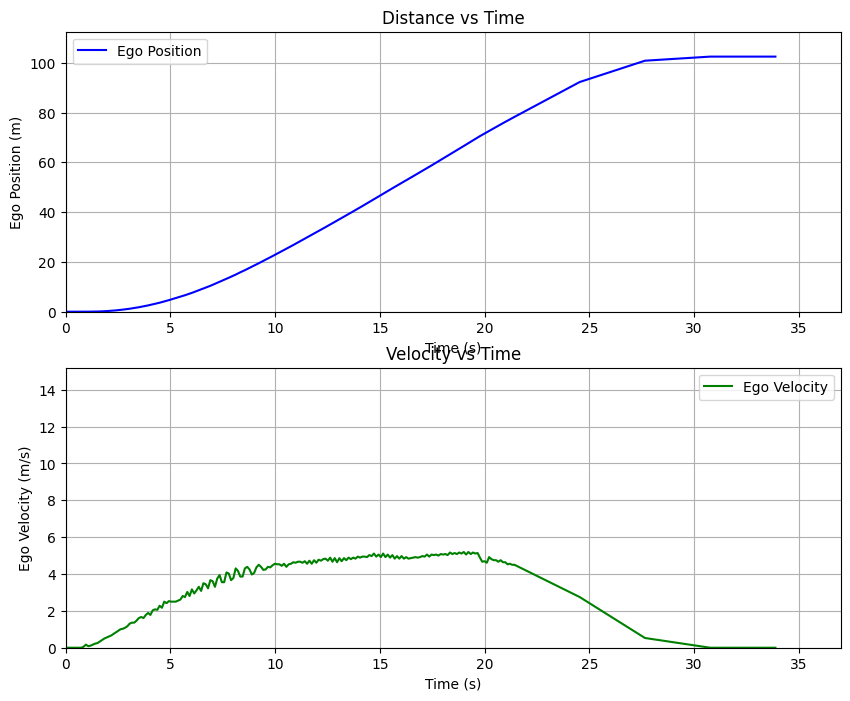

In [90]:
from IPython.display import HTML
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Select the DataFrame
df = pd_dataframes[4]

# Check if the required columns exist
if "Time(s)" in df.columns and "Ego_Position(m)" in df.columns and "Ego_Velocity(m/s)" in df.columns:
    # Initialize the figure and axes
    fig, ax = plt.subplots(2, 1, figsize=(10, 8))

    # Set up the first subplot for Distance vs Time
    ax[0].set_title("Distance vs Time")
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("Ego Position (m)")
    ax[0].grid(True)
    line1, = ax[0].plot([], [], label="Ego Position", color="blue")
    ax[0].legend()

    # Set up the second subplot for Velocity vs Time
    ax[1].set_title("Velocity vs Time")
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("Ego Velocity (m/s)")
    ax[1].grid(True)
    line2, = ax[1].plot([], [], label="Ego Velocity", color="green")
    ax[1].legend()

    # Initialize the data for animation
    def init():
        line1.set_data([], [])
        line2.set_data([], [])
        return line1, line2

    # Update function for animation
    def update(frame):
        # Update the data for the current frame
        time = df["Time(s)"][:frame]
        position = df["Ego_Position(m)"][:frame]
        velocity = df["Ego_Velocity(m/s)"][:frame]

        # Update the lines
        line1.set_data(time, position)
        line2.set_data(time, velocity)

        # Adjust the axis limits dynamically
        ax[0].set_xlim(0, df["Time(s)"].max())
        ax[0].set_ylim(0, df["Ego_Position(m)"].max() + 10)
        ax[1].set_xlim(0, df["Time(s)"].max())
        ax[1].set_ylim(0, df["Ego_Velocity(m/s)"].max() + 10)

        return line1, line2

    # Create the animation
    ani = FuncAnimation(fig, update, frames=len(df), init_func=init, blit=True, interval=50)

    # Embed the animation in the notebook
    HTML(ani.to_jshtml())  # Use this to display the animation in the notebook
else:
    print("The required columns are not present in the DataFrame.")